In [38]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers

import torch

print("Libraries loaded")

Libraries loaded


In [39]:
print("TensorFlow GPU:", tf.config.list_physical_devices('GPU'))
print("PyTorch GPU:", torch.cuda.is_available())

TensorFlow GPU: []
PyTorch GPU: False


In [24]:
def decode_abstract(inv_index):
    if not inv_index:
        return ""
    
    words = []
    for word, positions in inv_index.items():
        for pos in positions:
            words.append((pos, word))
    
    words = sorted(words)
    return " ".join([w for _, w in words])

Just the imports, requests will be for "openalex"

In [25]:
def fetch_openalex_data(n_pages=50):
    works = []
    
    base_url = "https://api.openalex.org/works"
    cursor = "*"

    for i in range(n_pages):
        print(f"Fetching page {i+1}...")

        params = {
            "filter": "from_publication_date:2015-01-01,to_publication_date:2018-12-31",
            "per_page": 200,
            "cursor": cursor
        }

        response = requests.get(base_url, params=params)
        
        if response.status_code != 200:
            print("Error:", response.text)
            break

        data = response.json()

        if "results" not in data:
            print("Unexpected response:", data)
            break

        for work in data["results"]:
            works.append({
                "title": work.get("title"),
                "abstract": decode_abstract(work.get("abstract_inverted_index")),
                "year": work.get("publication_year"),
                "num_authors": len(work.get("authorships", [])),
                "num_references": len(work.get("referenced_works", [])),
                "citation_count": work.get("cited_by_count")
            })

        cursor = data["meta"].get("next_cursor")
        if not cursor:
            break

        time.sleep(1)  # rate limit

    return pd.DataFrame(works)

In [26]:
df = fetch_openalex_data(n_pages=50)

df.to_csv("papers.csv", index=False)

print("Dataset shape:", df.shape)

Fetching page 1...
Fetching page 2...
Fetching page 3...
Fetching page 4...
Fetching page 5...
Fetching page 6...
Fetching page 7...
Fetching page 8...
Fetching page 9...
Fetching page 10...
Fetching page 11...
Fetching page 12...
Fetching page 13...
Fetching page 14...
Fetching page 15...
Fetching page 16...
Fetching page 17...
Fetching page 18...
Fetching page 19...
Fetching page 20...
Fetching page 21...
Fetching page 22...
Fetching page 23...
Fetching page 24...
Fetching page 25...
Fetching page 26...
Fetching page 27...
Fetching page 28...
Fetching page 29...
Fetching page 30...
Fetching page 31...
Fetching page 32...
Fetching page 33...
Fetching page 34...
Fetching page 35...
Fetching page 36...
Fetching page 37...
Fetching page 38...
Fetching page 39...
Fetching page 40...
Fetching page 41...
Fetching page 42...
Fetching page 43...
Fetching page 44...
Fetching page 45...
Fetching page 46...
Fetching page 47...
Fetching page 48...
Fetching page 49...
Fetching page 50...
Dataset s

In [27]:
df = df.dropna(subset=["title", "year", "citation_count"])

df["abstract"] = df["abstract"].fillna("")

current_year = 2024
df["citation_per_year"] = df["citation_count"] / (current_year - df["year"] + 1)

print("Cleaned shape:", df.shape)

Cleaned shape: (10000, 7)


In [ ]:
df["text"] = df["title"] + " " + df["abstract"]

df["title_len"] = df["title"].apply(lambda x: len(x.split()))
df["abstract_len"] = df["abstract"].apply(lambda x: len(x.split()))
df["refs_per_author"] = df["num_references"] / (df["num_authors"] + 1)
df["log_refs"] = np.log1p(df["num_references"])
df["log_authors"] = np.log1p(df["num_authors"])
df["year_norm"] = df["year"] - df["year"].min()

vectorizer = TfidfVectorizer(max_features=5000)
X_text = vectorizer.fit_transform(df["text"])

In [ ]:
X_numeric = df[[
    "num_authors",
    "num_references",
    "year",
    "title_len",
    "abstract_len",
    "refs_per_author",
    "log_refs",
    "log_authors",
    "year_norm"
]].values

In [30]:
X = hstack([X_text, X_numeric]).tocsr()

y_reg = df["citation_per_year"]

threshold = df["citation_per_year"].quantile(0.8)
y_clf = (df["citation_per_year"] > threshold).astype(int)

In [31]:
train_mask = (df["year"] <= 2017).values
test_mask = (df["year"] == 2018).values

X_train = X[train_mask]
X_test = X[test_mask]

y_train_reg = y_reg[train_mask]
y_test_reg = y_reg[test_mask]

y_train_clf = y_clf[train_mask]
y_test_clf = y_clf[test_mask]

print("Train years:", df[train_mask]["year"].unique())
print("Test years:", df[test_mask]["year"].unique())

Train years: [2016 2015 2017]
Test years: [2018]


In [ ]:
y_train_log = np.log1p(y_train_reg)
y_test_log = np.log1p(y_test_reg)

reg_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    n_jobs=-1
)

reg_model.fit(X_train, y_train_log)

y_pred_log = reg_model.predict(X_test)
y_pred_reg = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("\nREGRESSION RESULTS (FIXED)")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


REGRESSION RESULTS
MAE: 170.37134090989332
RMSE: 611.6804613317696
R²: -0.8363390344260173


In [ ]:
scale_pos_weight = len(y_train_clf[y_train_clf == 0]) / len(y_train_clf[y_train_clf == 1])

clf_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

clf_model.fit(X_train, y_train_clf)

# PROBABILITY
y_probs = clf_model.predict_proba(X_test)[:,1]

# THRESHOLD
y_pred_clf = (y_probs > 0.2).astype(int)

print("\nCLASSIFICATION RESULTS (FIXED)")
print(classification_report(y_test_clf, y_pred_clf))
print("ROC-AUC:", roc_auc_score(y_test_clf, y_probs))


CLASSIFICATION RESULTS
Accuracy: 0.7295568752855185
              precision    recall  f1-score   support

           0       0.73      1.00      0.84      1597
           1       0.50      0.01      0.02       592

    accuracy                           0.73      2189
   macro avg       0.62      0.50      0.43      2189
weighted avg       0.67      0.73      0.62      2189



In [ ]:
# DENSE CONVERSION (küçük subset ile başla yoksa RAM yanar)
X_train_dense = X_train[:5000].toarray()
y_train_dense = y_train_clf[:5000]

X_test_dense = X_test[:2000].toarray()
y_test_dense = y_test_clf[:2000]

model = tf.keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_dense.shape[1],)),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train_dense,
    y_train_dense,
    epochs=10,
    batch_size=32,
    class_weight={0:1, 1:3}
)

nn_probs = model.predict(X_test_dense)
nn_pred = (nn_probs > 0.2).astype(int)

print("\nNEURAL NETWORK RESULTS")
print(classification_report(y_test_dense, nn_pred))

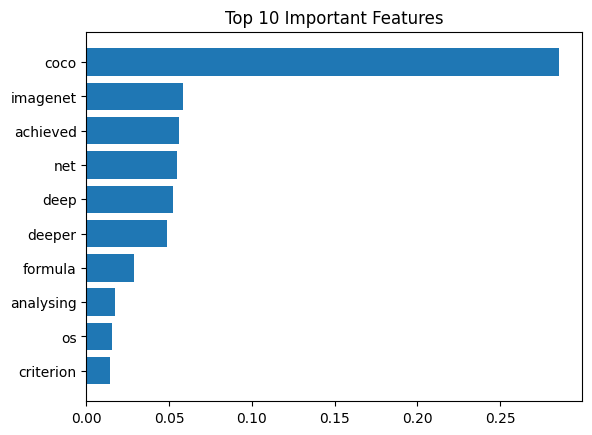

In [34]:
importances = reg_model.feature_importances_

feature_names = (
    vectorizer.get_feature_names_out().tolist() +
    ["num_authors", "num_references", "year", "title_len", "abstract_len", "refs_per_author"]
)

indices = np.argsort(importances)[-10:]

plt.figure()
plt.title("Top 10 Important Features")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.show()